In [1]:
# =========================
# CELL 1 — Build dataframe for Bd→Dπ and Bd→DK: PDG + Belle + LHCb + QCDF
# =========================
import numpy as np
import pandas as pd

# -------- helpers ----------
def quad(*xs):
    xs = np.array(xs, dtype=float)
    return float(np.sqrt(np.sum(xs**2)))

# -------- channel labels ----------
channels = {
    "Dpi": r"$B^0\to D\pi$",
    "DK":  r"$B^0\to DK$",
}

# -------- PDG averages (from your PDG screenshot) ----------
pdg = {
    "Dpi": dict(val=2.51e-3, err_lo=0.08e-3, err_hi=0.08e-3, label="PDG avg"),
    "DK":  dict(val=2.05e-4, err_lo=0.08e-4, err_hi=0.08e-4, label="PDG avg"),
}

# -------- Belle (Waheed et al., PRD 105, 012003 (2022)) ----------
# B(B̅0→D+π−)=(2.48±0.01±0.09±0.04)×10−3
# B(B̅0→D+K−)=(2.03±0.05±0.07±0.03)×10−4
belle = {
    "Dpi": dict(val=2.48e-3,
                err_lo=quad(0.01e-3, 0.09e-3, 0.04e-3),
                err_hi=quad(0.01e-3, 0.09e-3, 0.04e-3),
                label="Belle (2022)"),
    "DK":  dict(val=2.03e-4,
                err_lo=quad(0.05e-4, 0.07e-4, 0.03e-4),
                err_hi=quad(0.05e-4, 0.07e-4, 0.03e-4),
                label="Belle (2022)"),
}

# -------- LHCb (Aaij et al., PRD 87 (2013) 092001, arXiv:1304.2053) ----------
# B(B0→D+π−)=(2.52±0.13_stat±0.09_syst±0.11_fs/fd)×10−3
lhcb_2013 = {
    "Dpi": dict(val=2.52e-3,
                err_lo=quad(0.13e-3, 0.09e-3, 0.11e-3),
                err_hi=quad(0.13e-3, 0.09e-3, 0.11e-3),
                label="LHCb (2013)"),
    # If you later want to add their DK number too, add it here.
}

# -------- QCDF / SM predictions (from your screenshots) ----------
# Bordone et al. (2020): QCDF prediction for B̅0→D+K− is 0.326±0.015 in units 10^-3
bordone_qcdf = {
    "DK": dict(val=0.326e-3, err_lo=0.015e-3, err_hi=0.015e-3, label="QCDF (Bordone+ 2020)"),
}

# Iguro & Kitahara (2020): SM/QCDF expectation quoted for B̅0→D+π−
iguro_qcdf = {
    "Dpi": dict(val=3.93e-3, err_lo=0.42e-3, err_hi=0.43e-3, label="SM/QCDF (Iguro+Kitahara 2020)"),
    # (Optional) they also quote ~3.26e-4 for DK; we omit to avoid double DK theory points
    # "DK":  dict(val=3.26e-4, err_lo=0.15e-4, err_hi=0.15e-4, label="SM/QCDF (Iguro+Kitahara 2020)"),
}

# -------- build long-form dataframe ----------
records = []

def add_source(src_dict, source_name):
    for ch, d in src_dict.items():
        records.append(dict(
            channel_key=ch,
            channel_label=channels[ch],
            source=source_name,
            label=d["label"],
            val=d["val"],
            err_lo=d["err_lo"],
            err_hi=d["err_hi"],
        ))

add_source(pdg, "PDG")
add_source(belle, "Belle")
add_source(lhcb_2013, "LHCb (2013)")
add_source(bordone_qcdf, "QCDF (Bordone+2020)")
add_source(iguro_qcdf, "QCDF (Iguro+Kitahara 2020)")

df = pd.DataFrame.from_records(records)
df

,channel_key,channel_label,source,label,val,err_lo,err_hi
0,Dpi,$B^0\to D\pi$,PDG,PDG avg,0.002510,0.000080,0.000080
1,DK,$B^0\to DK$,PDG,PDG avg,0.000205,0.000008,0.000008
2,Dpi,$B^0\to D\pi$,Belle,Belle (2022),0.002480,0.000099,0.000099
3,DK,$B^0\to DK$,Belle,Belle (2022),0.000203,0.000009,0.000009
4,Dpi,$B^0\to D\pi$,LHCb (2013),LHCb (2013),0.002520,0.000193,0.000193
5,DK,$B^0\to DK$,QCDF (Bordone+2020),QCDF (Bordone+ 2020),0.000326,0.000015,0.000015
6,Dpi,$B^0\to D\pi$,QCDF (Iguro+Kitahara 2020),SM/QCDF (Iguro+Kitahara 2020),0.003930,0.000420,0.000430


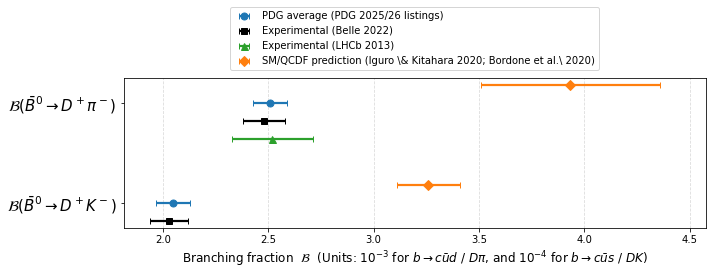

In [2]:
# =========================
# CELL 2 — Forest plot (scaled x-axis like the example) + PDG/Belle/LHCb/QCDF
# =========================
import matplotlib.pyplot as plt

# Choose exactly ONE theory prediction per channel (so you don't get two DK theory points)
theory_choice = {
    "Dpi": "QCDF (Iguro+Kitahara 2020)",   # Dπ theory from Iguro & Kitahara
    "DK":  "QCDF (Bordone+2020)",          # DK theory from Bordone et al.
}

# Mode-dependent scaling (matches the example figure)
#   Dπ shown in units of 1e-3, DK shown in units of 1e-4
scale = {"Dpi": 1e-3, "DK": 1e-4}

# Plot order (top to bottom)
modes = [
    ("Dpi", r"$\mathcal{B}(\bar{B}^0 \to D^+\pi^-)$"),
    ("DK",  r"$\mathcal{B}(\bar{B}^0 \to D^+K^-)$"),
]
ypos = np.arange(len(modes))[::-1]

def get_row(source, ch_key):
    r = df[(df["source"] == source) & (df["channel_key"] == ch_key)]
    return None if r.empty else r.iloc[0]

fig, ax = plt.subplots(figsize=(10, 4.4))

# Marker styles
styles = {
    "PDG":        dict(fmt="o", color="tab:blue",   ms=7.0, lw=2.2),
    "Belle":      dict(fmt="s", color="black",      ms=6.7, lw=2.2),
    "LHCb (2013)":dict(fmt="^", color="tab:green",  ms=7.0, lw=2.2),
    "SM":         dict(fmt="D", color="tab:orange", ms=7.0, lw=2.2),
}

# Legend labels (with sources)
pdg_label   = r"PDG average (PDG 2025/26 listings)"
belle_label = r"Experimental (Belle 2022)"
lhcb_label  = r"Experimental (LHCb 2013)"
sm_label    = r"SM/QCDF prediction (Iguro \& Kitahara 2020; Bordone et al.\ 2020)"

legend_done = set()

# vertical offsets within each mode row (avoid overlap)
dy = {
    "PDG": 0.00,
    "Belle": -0.18,
    "LHCb (2013)": -0.36,
    "SM": +0.18,
}

for y, (ch_key, ylab) in zip(ypos, modes):

    s = scale[ch_key]

    # --- PDG ---
    r = get_row("PDG", ch_key)
    if r is not None:
        x = float(r["val"]) / s
        xe_lo = float(r["err_lo"]) / s
        xe_hi = float(r["err_hi"]) / s
        label = pdg_label if "PDG" not in legend_done else None
        legend_done.add("PDG")
        ax.errorbar(
            x, y + dy["PDG"],
            xerr=np.array([[xe_lo], [xe_hi]]),
            capsize=3,
            label=label,
            **styles["PDG"]
        )

    # --- Belle ---
    r = get_row("Belle", ch_key)
    if r is not None:
        x = float(r["val"]) / s
        xe_lo = float(r["err_lo"]) / s
        xe_hi = float(r["err_hi"]) / s
        label = belle_label if "Belle" not in legend_done else None
        legend_done.add("Belle")
        ax.errorbar(
            x, y + dy["Belle"],
            xerr=np.array([[xe_lo], [xe_hi]]),
            capsize=3,
            label=label,
            **styles["Belle"]
        )

    # --- LHCb 2013 (only Dπ present in df) ---
    r = get_row("LHCb (2013)", ch_key)
    if r is not None:
        x = float(r["val"]) / s
        xe_lo = float(r["err_lo"]) / s
        xe_hi = float(r["err_hi"]) / s
        label = lhcb_label if "LHCb" not in legend_done else None
        legend_done.add("LHCb")
        ax.errorbar(
            x, y + dy["LHCb (2013)"],
            xerr=np.array([[xe_lo], [xe_hi]]),
            capsize=3,
            label=label,
            **styles["LHCb (2013)"]
        )

    # --- SM/QCDF ---
    r = get_row(theory_choice[ch_key], ch_key)
    if r is not None:
        x = float(r["val"]) / s
        xe_lo = float(r["err_lo"]) / s
        xe_hi = float(r["err_hi"]) / s
        label = sm_label if "SM" not in legend_done else None
        legend_done.add("SM")
        ax.errorbar(
            x, y + dy["SM"],
            xerr=np.array([[xe_lo], [xe_hi]]),
            capsize=3,
            label=label,
            **styles["SM"]
        )

# Y labels
ax.set_yticks(ypos)
ax.set_yticklabels([yl for _, yl in modes], fontsize=15)

# X label (scaled axis explanation like the example)
ax.set_xlabel(
    r"Branching fraction  $\mathcal{B}$  "
    r"(Units: $10^{-3}$ for $b\to c\bar{u}d$ / $D\pi$, and $10^{-4}$ for $b\to c\bar{u}s$ / $DK$)",
    fontsize=12
)

# Grid and bounds
ax.grid(True, axis="x", linestyle="--", alpha=0.45)
ax.grid(False, axis="y")

# Tight x-limits in scaled units (based on plotted entries)
xs, xerrs = [], []
for ch_key, _ in modes:
    s = scale[ch_key]
    keep_sources = ["PDG", "Belle", "LHCb (2013)", theory_choice[ch_key]]
    sub = df[(df["channel_key"] == ch_key) & (df["source"].isin(keep_sources))]
    xs.extend((sub["val"].values / s).tolist())
    xerrs.extend((sub["err_lo"].values / s).tolist())
    xerrs.extend((sub["err_hi"].values / s).tolist())

xmin = min(xs) - 0.5 * max(xerrs)
xmax = max(xs) + 1.5* max(xerrs)
ax.set_xlim(xmin, xmax)

# Legend above (not blocking points)
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

In [3]:
# =========================
# CELL 1 — Build dataframe for Bd→Dπ and Bd→DK: PDG + Belle + LHCb + QCDF + (This work) + (Projection)
# =========================
import numpy as np
import pandas as pd

# -------- helpers ----------
def quad(*xs):
    xs = np.array(xs, dtype=float)
    return float(np.sqrt(np.sum(xs**2)))

# -------- channel labels ----------
channels = {
    "Dpi": r"$B^0\to D\pi$",
    "DK":  r"$B^0\to DK$",
}

# -------- PDG averages (from your PDG screenshot) ----------
pdg = {
    "Dpi": dict(val=2.51e-3, err_lo=0.08e-3, err_hi=0.08e-3, label="PDG avg"),
    "DK":  dict(val=2.05e-4, err_lo=0.08e-4, err_hi=0.08e-4, label="PDG avg"),
}

# -------- Belle (Waheed et al., PRD 105, 012003 (2022)) ----------
belle = {
    "Dpi": dict(val=2.48e-3,
                err_lo=quad(0.01e-3, 0.09e-3, 0.04e-3),
                err_hi=quad(0.01e-3, 0.09e-3, 0.04e-3),
                label="Belle (2022)"),
    "DK":  dict(val=2.03e-4,
                err_lo=quad(0.05e-4, 0.07e-4, 0.03e-4),
                err_hi=quad(0.05e-4, 0.07e-4, 0.03e-4),
                label="Belle (2022)"),
}

# -------- LHCb (Aaij et al., PRD 87 (2013) 092001, arXiv:1304.2053) ----------
lhcb_2013 = {
    "Dpi": dict(val=2.52e-3,
                err_lo=quad(0.13e-3, 0.09e-3, 0.11e-3),
                err_hi=quad(0.13e-3, 0.09e-3, 0.11e-3),
                label="LHCb (2013)"),
}

# -------- QCDF / SM predictions ----------
bordone_qcdf = {
    "DK": dict(val=0.326e-3, err_lo=0.015e-3, err_hi=0.015e-3, label="QCDF (Bordone+ 2020)"),
}
iguro_qcdf = {
    "Dpi": dict(val=3.93e-3, err_lo=0.42e-3, err_hi=0.43e-3, label="SM/QCDF (Iguro+Kitahara 2020)"),
}

# -------- YOUR RESULTS (1 fb^-1) ----------
# B_Dpi = (2.1646 ± 0.0073_stat ± 0.0764_ext) × 10^-3
# B_DK  = (1.9333 ± 0.0137_stat ± 0.0661_ext) × 10^-4
this_work_1fb = {
    "Dpi": dict(val=2.1646e-3,
                err_lo=quad(0.0073e-3, 0.0764e-3),
                err_hi=quad(0.0073e-3, 0.0764e-3),
                label=r"This work (1 fb$^{-1}$)"),
    "DK":  dict(val=1.9333e-4,
                err_lo=quad(0.0137e-4, 0.0661e-4),
                err_hi=quad(0.0137e-4, 0.0661e-4),
                label=r"This work (1 fb$^{-1}$)"),
}

# -------- YOUR PROJECTION (30 fb^-1) ----------
# σ_stat(B0→Dπ)=0.0013×10^-3, σ_stat(B0→DK)=0.0025×10^-4 ; keep same ext uncertainties
proj_30fb = {
    "Dpi": dict(val=2.1646e-3,
                err_lo=quad(0.0013e-3, 0.0764e-3),
                err_hi=quad(0.0013e-3, 0.0764e-3),
                label=r"Projection (30 fb$^{-1}$)"),
    "DK":  dict(val=1.9333e-4,
                err_lo=quad(0.0025e-4, 0.0661e-4),
                err_hi=quad(0.0025e-4, 0.0661e-4),
                label=r"Projection (30 fb$^{-1}$)"),
}

# -------- build long-form dataframe ----------
records = []

def add_source(src_dict, source_name):
    for ch, d in src_dict.items():
        records.append(dict(
            channel_key=ch,
            channel_label=channels[ch],
            source=source_name,
            label=d["label"],
            val=d["val"],
            err_lo=d["err_lo"],
            err_hi=d["err_hi"],
        ))

add_source(pdg, "PDG")
add_source(belle, "Belle")
add_source(lhcb_2013, "LHCb (2013)")
add_source(bordone_qcdf, "QCDF (Bordone+2020)")
add_source(iguro_qcdf, "QCDF (Iguro+Kitahara 2020)")
add_source(this_work_1fb, "This work (1 fb^-1)")
add_source(proj_30fb, "Projection (30 fb^-1)")

df = pd.DataFrame.from_records(records)
df

,channel_key,channel_label,source,label,val,err_lo,err_hi
0,Dpi,$B^0\to D\pi$,PDG,PDG avg,0.002510,0.000080,0.000080
1,DK,$B^0\to DK$,PDG,PDG avg,0.000205,0.000008,0.000008
2,Dpi,$B^0\to D\pi$,Belle,Belle (2022),0.002480,0.000099,0.000099
3,DK,$B^0\to DK$,Belle,Belle (2022),0.000203,0.000009,0.000009
4,Dpi,$B^0\to D\pi$,LHCb (2013),LHCb (2013),0.002520,0.000193,0.000193
5,DK,$B^0\to DK$,QCDF (Bordone+2020),QCDF (Bordone+ 2020),0.000326,0.000015,0.000015
6,Dpi,$B^0\to D\pi$,QCDF (Iguro+Kitahara 2020),SM/QCDF (Iguro+Kitahara 2020),0.003930,0.000420,0.000430
7,Dpi,$B^0\to D\pi$,This work (1 fb^-1),This work (1 fb$^{-1}$),0.002165,0.000077,0.000077
8,DK,$B^0\to DK$,This work (1 fb^-1),This work (1 fb$^{-1}$),0.000193,0.000007,0.000007
9,Dpi,$B^0\to D\pi$,Projection (30 fb^-1),Projection (30 fb$^{-1}$),0.002165,0.000076,0.000076


In [4]:
# =========================
# CELL 1 — Build dataframe for Bd→Dπ and Bd→DK: PDG + Belle + LHCb + QCDF + (This work) + (Projection)
# =========================
import numpy as np
import pandas as pd

# -------- helpers ----------
def quad(*xs):
    xs = np.array(xs, dtype=float)
    return float(np.sqrt(np.sum(xs**2)))

# -------- channel labels ----------
channels = {
    "Dpi": r"$B^0\to D\pi$",
    "DK":  r"$B^0\to DK$",
}

# -------- PDG averages (from your PDG screenshot) ----------
pdg = {
    "Dpi": dict(val=2.51e-3, err_lo=0.08e-3, err_hi=0.08e-3, label="PDG avg"),
    "DK":  dict(val=2.05e-4, err_lo=0.08e-4, err_hi=0.08e-4, label="PDG avg"),
}

# -------- Belle (Waheed et al., PRD 105, 012003 (2022)) ----------
belle = {
    "Dpi": dict(val=2.48e-3,
                err_lo=quad(0.01e-3, 0.09e-3, 0.04e-3),
                err_hi=quad(0.01e-3, 0.09e-3, 0.04e-3),
                label="Belle (2022)"),
    "DK":  dict(val=2.03e-4,
                err_lo=quad(0.05e-4, 0.07e-4, 0.03e-4),
                err_hi=quad(0.05e-4, 0.07e-4, 0.03e-4),
                label="Belle (2022)"),
}

# -------- LHCb (Aaij et al., PRD 87 (2013) 092001, arXiv:1304.2053) ----------
lhcb_2013 = {
    "Dpi": dict(val=2.52e-3,
                err_lo=quad(0.13e-3, 0.09e-3, 0.11e-3),
                err_hi=quad(0.13e-3, 0.09e-3, 0.11e-3),
                label="LHCb (2013)"),
}

# -------- QCDF / SM predictions ----------
bordone_qcdf = {
    "DK": dict(val=0.326e-3, err_lo=0.015e-3, err_hi=0.015e-3, label="QCDF (Bordone+ 2020)"),
}
iguro_qcdf = {
    "Dpi": dict(val=3.93e-3, err_lo=0.42e-3, err_hi=0.43e-3, label="SM/QCDF (Iguro+Kitahara 2020)"),
}

# -------- YOUR RESULTS (1 fb^-1) ----------
# B_Dpi = (2.1646 ± 0.0073_stat ± 0.0764_ext) × 10^-3
# B_DK  = (1.9333 ± 0.0137_stat ± 0.0661_ext) × 10^-4
this_work_1fb = {
    "Dpi": dict(val=2.1646e-3,
                err_lo=quad(0.0073e-3, 0.0764e-3),
                err_hi=quad(0.0073e-3, 0.0764e-3),
                label=r"This work (1 fb$^{-1}$)"),
    "DK":  dict(val=1.9333e-4,
                err_lo=quad(0.0137e-4, 0.0661e-4),
                err_hi=quad(0.0137e-4, 0.0661e-4),
                label=r"This work (1 fb$^{-1}$)"),
}

# -------- YOUR PROJECTION (30 fb^-1) ----------
# σ_stat(B0→Dπ)=0.0013×10^-3, σ_stat(B0→DK)=0.0025×10^-4 ; keep same ext uncertainties
proj_30fb = {
    "Dpi": dict(val=2.1646e-3,
                err_lo=quad(0.0013e-3, 0.0764e-3),
                err_hi=quad(0.0013e-3, 0.0764e-3),
                label=r"Projection (30 fb$^{-1}$)"),
    "DK":  dict(val=1.9333e-4,
                err_lo=quad(0.0025e-4, 0.0661e-4),
                err_hi=quad(0.0025e-4, 0.0661e-4),
                label=r"Projection (30 fb$^{-1}$)"),
}

# -------- build long-form dataframe ----------
records = []

def add_source(src_dict, source_name):
    for ch, d in src_dict.items():
        records.append(dict(
            channel_key=ch,
            channel_label=channels[ch],
            source=source_name,
            label=d["label"],
            val=d["val"],
            err_lo=d["err_lo"],
            err_hi=d["err_hi"],
        ))

add_source(pdg, "PDG")
add_source(belle, "Belle")
add_source(lhcb_2013, "LHCb (2013)")
add_source(bordone_qcdf, "QCDF (Bordone+2020)")
add_source(iguro_qcdf, "QCDF (Iguro+Kitahara 2020)")
add_source(this_work_1fb, "This work (1 fb^-1)")
add_source(proj_30fb, "Projection (30 fb^-1)")

df = pd.DataFrame.from_records(records)
df

,channel_key,channel_label,source,label,val,err_lo,err_hi
0,Dpi,$B^0\to D\pi$,PDG,PDG avg,0.002510,0.000080,0.000080
1,DK,$B^0\to DK$,PDG,PDG avg,0.000205,0.000008,0.000008
2,Dpi,$B^0\to D\pi$,Belle,Belle (2022),0.002480,0.000099,0.000099
3,DK,$B^0\to DK$,Belle,Belle (2022),0.000203,0.000009,0.000009
4,Dpi,$B^0\to D\pi$,LHCb (2013),LHCb (2013),0.002520,0.000193,0.000193
5,DK,$B^0\to DK$,QCDF (Bordone+2020),QCDF (Bordone+ 2020),0.000326,0.000015,0.000015
6,Dpi,$B^0\to D\pi$,QCDF (Iguro+Kitahara 2020),SM/QCDF (Iguro+Kitahara 2020),0.003930,0.000420,0.000430
7,Dpi,$B^0\to D\pi$,This work (1 fb^-1),This work (1 fb$^{-1}$),0.002165,0.000077,0.000077
8,DK,$B^0\to DK$,This work (1 fb^-1),This work (1 fb$^{-1}$),0.000193,0.000007,0.000007
9,Dpi,$B^0\to D\pi$,Projection (30 fb^-1),Projection (30 fb$^{-1}$),0.002165,0.000076,0.000076


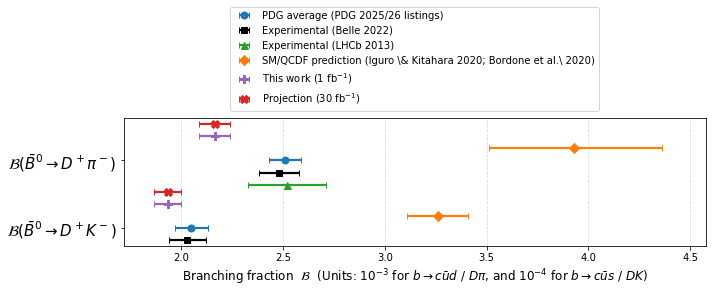

In [5]:
# =========================
# CELL 2 — Forest plot (scaled x-axis like the example) + PDG/Belle/LHCb/QCDF + your results
# =========================
import matplotlib.pyplot as plt
import numpy as np

theory_choice = {
    "Dpi": "QCDF (Iguro+Kitahara 2020)",
    "DK":  "QCDF (Bordone+2020)",
}

scale = {"Dpi": 1e-3, "DK": 1e-4}

modes = [
    ("Dpi", r"$\mathcal{B}(\bar{B}^0 \to D^+\pi^-)$"),
    ("DK",  r"$\mathcal{B}(\bar{B}^0 \to D^+K^-)$"),
]
ypos = np.arange(len(modes))[::-1]

def get_row(source, ch_key):
    r = df[(df["source"] == source) & (df["channel_key"] == ch_key)]
    return None if r.empty else r.iloc[0]

fig, ax = plt.subplots(figsize=(10, 4.8))

styles = {
    "PDG":                  dict(fmt="o", color="tab:blue",   ms=7.0, lw=2.2),
    "Belle":                dict(fmt="s", color="black",      ms=6.7, lw=2.2),
    "LHCb (2013)":          dict(fmt="^", color="tab:green",  ms=7.0, lw=2.2),
    "SM":                   dict(fmt="D", color="tab:orange", ms=7.0, lw=2.2),
    "This work (1 fb^-1)":  dict(fmt="P", color="tab:purple", ms=7.2, lw=2.2),
    "Projection (30 fb^-1)":dict(fmt="X", color="tab:red",    ms=7.2, lw=2.2),
}

pdg_label   = r"PDG average (PDG 2025/26 listings)"
belle_label = r"Experimental (Belle 2022)"
lhcb_label  = r"Experimental (LHCb 2013)"
sm_label    = r"SM/QCDF prediction (Iguro \& Kitahara 2020; Bordone et al.\ 2020)"
work1_label = r"This work (1 fb$^{-1}$)"
proj_label  = r"Projection (30 fb$^{-1}$)"

legend_done = set()

# vertical offsets within each mode row
dy = {
    "PDG": 0.00,
    "Belle": -0.18,
    "LHCb (2013)": -0.36,
    "SM": +0.18,
    "This work (1 fb^-1)": +0.36,
    "Projection (30 fb^-1)": +0.54,
}

for y, (ch_key, ylab) in zip(ypos, modes):
    s = scale[ch_key]

    # PDG
    r = get_row("PDG", ch_key)
    if r is not None:
        x = float(r["val"]) / s
        xe_lo = float(r["err_lo"]) / s
        xe_hi = float(r["err_hi"]) / s
        label = pdg_label if "PDG" not in legend_done else None
        legend_done.add("PDG")
        ax.errorbar(x, y + dy["PDG"], xerr=np.array([[xe_lo], [xe_hi]]),
                    capsize=3, label=label, **styles["PDG"])

    # Belle
    r = get_row("Belle", ch_key)
    if r is not None:
        x = float(r["val"]) / s
        xe_lo = float(r["err_lo"]) / s
        xe_hi = float(r["err_hi"]) / s
        label = belle_label if "Belle" not in legend_done else None
        legend_done.add("Belle")
        ax.errorbar(x, y + dy["Belle"], xerr=np.array([[xe_lo], [xe_hi]]),
                    capsize=3, label=label, **styles["Belle"])

    # LHCb 2013
    r = get_row("LHCb (2013)", ch_key)
    if r is not None:
        x = float(r["val"]) / s
        xe_lo = float(r["err_lo"]) / s
        xe_hi = float(r["err_hi"]) / s
        label = lhcb_label if "LHCb" not in legend_done else None
        legend_done.add("LHCb")
        ax.errorbar(x, y + dy["LHCb (2013)"], xerr=np.array([[xe_lo], [xe_hi]]),
                    capsize=3, label=label, **styles["LHCb (2013)"])

    # SM/QCDF
    r = get_row(theory_choice[ch_key], ch_key)
    if r is not None:
        x = float(r["val"]) / s
        xe_lo = float(r["err_lo"]) / s
        xe_hi = float(r["err_hi"]) / s
        label = sm_label if "SM" not in legend_done else None
        legend_done.add("SM")
        ax.errorbar(x, y + dy["SM"], xerr=np.array([[xe_lo], [xe_hi]]),
                    capsize=3, label=label, **styles["SM"])

    # This work (1 fb^-1)
    r = get_row("This work (1 fb^-1)", ch_key)
    if r is not None:
        x = float(r["val"]) / s
        xe_lo = float(r["err_lo"]) / s
        xe_hi = float(r["err_hi"]) / s
        label = work1_label if "This work (1 fb^-1)" not in legend_done else None
        legend_done.add("This work (1 fb^-1)")
        ax.errorbar(x, y + dy["This work (1 fb^-1)"], xerr=np.array([[xe_lo], [xe_hi]]),
                    capsize=3, label=label, **styles["This work (1 fb^-1)"])

    # Projection (30 fb^-1)
    r = get_row("Projection (30 fb^-1)", ch_key)
    if r is not None:
        x = float(r["val"]) / s
        xe_lo = float(r["err_lo"]) / s
        xe_hi = float(r["err_hi"]) / s
        label = proj_label if "Projection (30 fb^-1)" not in legend_done else None
        legend_done.add("Projection (30 fb^-1)")
        ax.errorbar(x, y + dy["Projection (30 fb^-1)"], xerr=np.array([[xe_lo], [xe_hi]]),
                    capsize=3, label=label, **styles["Projection (30 fb^-1)"])

ax.set_yticks(ypos)
ax.set_yticklabels([yl for _, yl in modes], fontsize=15)

ax.set_xlabel(
    r"Branching fraction  $\mathcal{B}$  "
    r"(Units: $10^{-3}$ for $b\to c\bar{u}d$ / $D\pi$, and $10^{-4}$ for $b\to c\bar{u}s$ / $DK$)",
    fontsize=12
)

ax.grid(True, axis="x", linestyle="--", alpha=0.45)
ax.grid(False, axis="y")

# x-limits from *all* plotted sources (including your new ones)
xs, xerrs = [], []
for ch_key, _ in modes:
    s = scale[ch_key]
    keep_sources = ["PDG", "Belle", "LHCb (2013)", theory_choice[ch_key],
                    "This work (1 fb^-1)", "Projection (30 fb^-1)"]
    sub = df[(df["channel_key"] == ch_key) & (df["source"].isin(keep_sources))]
    xs.extend((sub["val"].values / s).tolist())
    xerrs.extend((sub["err_lo"].values / s).tolist())
    xerrs.extend((sub["err_hi"].values / s).tolist())

xmin = min(xs) - 0.5 * max(xerrs)
xmax = max(xs) + 1.5 * max(xerrs)
ax.set_xlim(xmin, xmax)

ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

In [6]:
# =========================
# CELL 1 — Build dataframe for Bd→Dπ and Bd→DK:
# PDG + Belle + LHCb + QCDF + (This work 1 fb^-1 total) + (Projection 30 fb^-1 total)
# + (Projection 30 fb^-1 stat-only for overlay)
# =========================
import numpy as np
import pandas as pd

def quad(*xs):
    xs = np.array(xs, dtype=float)
    return float(np.sqrt(np.sum(xs**2)))

channels = {
    "Dpi": r"$B^0\to D\pi$",
    "DK":  r"$B^0\to DK$",
}

pdg = {
    "Dpi": dict(val=2.51e-3, err_lo=0.08e-3, err_hi=0.08e-3, label="PDG avg"),
    "DK":  dict(val=2.05e-4, err_lo=0.08e-4, err_hi=0.08e-4, label="PDG avg"),
}

belle = {
    "Dpi": dict(val=2.48e-3,
                err_lo=quad(0.01e-3, 0.09e-3, 0.04e-3),
                err_hi=quad(0.01e-3, 0.09e-3, 0.04e-3),
                label="Belle (2022)"),
    "DK":  dict(val=2.03e-4,
                err_lo=quad(0.05e-4, 0.07e-4, 0.03e-4),
                err_hi=quad(0.05e-4, 0.07e-4, 0.03e-4),
                label="Belle (2022)"),
}

lhcb_2013 = {
    "Dpi": dict(val=2.52e-3,
                err_lo=quad(0.13e-3, 0.09e-3, 0.11e-3),
                err_hi=quad(0.13e-3, 0.09e-3, 0.11e-3),
                label="LHCb (2013)"),
}

bordone_qcdf = {
    "DK": dict(val=0.326e-3, err_lo=0.015e-3, err_hi=0.015e-3, label="QCDF (Bordone+ 2020)"),
}
iguro_qcdf = {
    "Dpi": dict(val=3.93e-3, err_lo=0.42e-3, err_hi=0.43e-3, label="SM/QCDF (Iguro+Kitahara 2020)"),
}

this_work_1fb_total = {
    "Dpi": dict(val=2.1646e-3,
                err_lo=quad(0.0073e-3, 0.0764e-3),
                err_hi=quad(0.0073e-3, 0.0764e-3),
                label=r"This work (1 fb$^{-1}$)"),
    "DK":  dict(val=1.9333e-4,
                err_lo=quad(0.0137e-4, 0.0661e-4),
                err_hi=quad(0.0137e-4, 0.0661e-4),
                label=r"This work (1 fb$^{-1}$)"),
}

proj_30fb_total = {
    "Dpi": dict(val=2.1646e-3,
                err_lo=quad(0.0013e-3, 0.0764e-3),
                err_hi=quad(0.0013e-3, 0.0764e-3),
                label=r"Projection (30 fb$^{-1}$)"),
    "DK":  dict(val=1.9333e-4,
                err_lo=quad(0.0025e-4, 0.0661e-4),
                err_hi=quad(0.0025e-4, 0.0661e-4),
                label=r"Projection (30 fb$^{-1}$)"),
}

proj_30fb_statonly = {
    "Dpi": dict(val=2.1646e-3, err_lo=0.0013e-3, err_hi=0.0013e-3, label=r"Projection stat-only"),
    "DK":  dict(val=1.9333e-4, err_lo=0.0025e-4, err_hi=0.0025e-4, label=r"Projection stat-only"),
}

records = []

def add_source(src_dict, source_name):
    for ch, d in src_dict.items():
        records.append(dict(
            channel_key=ch,
            channel_label=channels[ch],
            source=source_name,
            label=d["label"],
            val=d["val"],
            err_lo=d["err_lo"],
            err_hi=d["err_hi"],
        ))

add_source(pdg, "PDG")
add_source(belle, "Belle")
add_source(lhcb_2013, "LHCb (2013)")
add_source(bordone_qcdf, "QCDF (Bordone+2020)")
add_source(iguro_qcdf, "QCDF (Iguro+Kitahara 2020)")
add_source(this_work_1fb_total, "This work (1 fb^-1)")
add_source(proj_30fb_total, "Projection (30 fb^-1)")
add_source(proj_30fb_statonly, "Projection (30 fb^-1) stat-only")

df = pd.DataFrame.from_records(records)
df

,channel_key,channel_label,source,label,val,err_lo,err_hi
0,Dpi,$B^0\to D\pi$,PDG,PDG avg,0.002510,8.000000e-05,8.000000e-05
1,DK,$B^0\to DK$,PDG,PDG avg,0.000205,8.000000e-06,8.000000e-06
2,Dpi,$B^0\to D\pi$,Belle,Belle (2022),0.002480,9.899495e-05,9.899495e-05
3,DK,$B^0\to DK$,Belle,Belle (2022),0.000203,9.110434e-06,9.110434e-06
4,Dpi,$B^0\to D\pi$,LHCb (2013),LHCb (2013),0.002520,1.926136e-04,1.926136e-04
5,DK,$B^0\to DK$,QCDF (Bordone+2020),QCDF (Bordone+ 2020),0.000326,1.500000e-05,1.500000e-05
6,Dpi,$B^0\to D\pi$,QCDF (Iguro+Kitahara 2020),SM/QCDF (Iguro+Kitahara 2020),0.003930,4.200000e-04,4.300000e-04
7,Dpi,$B^0\to D\pi$,This work (1 fb^-1),This work (1 fb$^{-1}$),0.002165,7.674796e-05,7.674796e-05
8,DK,$B^0\to DK$,This work (1 fb^-1),This work (1 fb$^{-1}$),0.000193,6.750481e-06,6.750481e-06
9,Dpi,$B^0\to D\pi$,Projection (30 fb^-1),Projection (30 fb$^{-1}$),0.002165,7.641106e-05,7.641106e-05


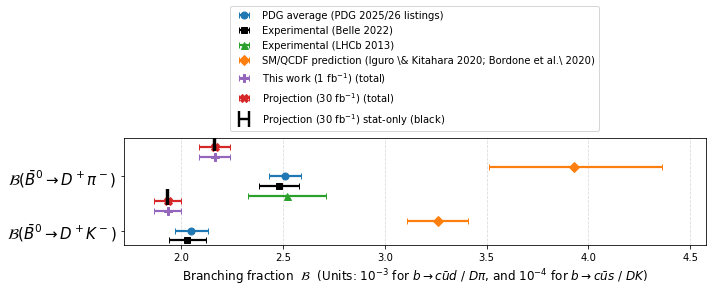

In [7]:
# =========================
# CELL 2 — Forest plot + *visible* stat-only overlay for 30 fb^-1
# (stat-only drawn slightly above the red projection point + big caps)
# =========================
import matplotlib.pyplot as plt
import numpy as np

theory_choice = {
    "Dpi": "QCDF (Iguro+Kitahara 2020)",
    "DK":  "QCDF (Bordone+2020)",
}

scale = {"Dpi": 1e-3, "DK": 1e-4}

modes = [
    ("Dpi", r"$\mathcal{B}(\bar{B}^0 \to D^+\pi^-)$"),
    ("DK",  r"$\mathcal{B}(\bar{B}^0 \to D^+K^-)$"),
]
ypos = np.arange(len(modes))[::-1]

def get_row(source, ch_key):
    r = df[(df["source"] == source) & (df["channel_key"] == ch_key)]
    return None if r.empty else r.iloc[0]

fig, ax = plt.subplots(figsize=(10, 4.8))

styles = {
    "PDG":                   dict(fmt="o", color="tab:blue",   ms=7.0, lw=2.2),
    "Belle":                 dict(fmt="s", color="black",      ms=6.7, lw=2.2),
    "LHCb (2013)":           dict(fmt="^", color="tab:green",  ms=7.0, lw=2.2),
    "SM":                    dict(fmt="D", color="tab:orange", ms=7.0, lw=2.2),
    "This work (1 fb^-1)":   dict(fmt="P", color="tab:purple", ms=7.2, lw=2.2),
    "Projection (30 fb^-1)": dict(fmt="X", color="tab:red",    ms=7.2, lw=2.2),
}

pdg_label   = r"PDG average (PDG 2025/26 listings)"
belle_label = r"Experimental (Belle 2022)"
lhcb_label  = r"Experimental (LHCb 2013)"
sm_label    = r"SM/QCDF prediction (Iguro \& Kitahara 2020; Bordone et al.\ 2020)"
work1_label = r"This work (1 fb$^{-1}$) (total)"
proj_label  = r"Projection (30 fb$^{-1}$) (total)"
proj_stat_label = r"Projection (30 fb$^{-1}$) stat-only (black)"

legend_done = set()

dy = {
    "PDG": 0.00,
    "Belle": -0.18,
    "LHCb (2013)": -0.36,
    "SM": +0.18,
    "This work (1 fb^-1)": +0.36,
    "Projection (30 fb^-1)": +0.54,
}

# small vertical offset so the stat-only bar is not buried inside the red total bar
STAT_OVERLAY_DY = 0.08

for y, (ch_key, _) in zip(ypos, modes):
    s = scale[ch_key]

    # PDG
    r = get_row("PDG", ch_key)
    if r is not None:
        x = float(r["val"]) / s
        xe_lo = float(r["err_lo"]) / s
        xe_hi = float(r["err_hi"]) / s
        label = pdg_label if "PDG" not in legend_done else None
        legend_done.add("PDG")
        ax.errorbar(x, y + dy["PDG"], xerr=np.array([[xe_lo], [xe_hi]]),
                    capsize=3, label=label, **styles["PDG"])

    # Belle
    r = get_row("Belle", ch_key)
    if r is not None:
        x = float(r["val"]) / s
        xe_lo = float(r["err_lo"]) / s
        xe_hi = float(r["err_hi"]) / s
        label = belle_label if "Belle" not in legend_done else None
        legend_done.add("Belle")
        ax.errorbar(x, y + dy["Belle"], xerr=np.array([[xe_lo], [xe_hi]]),
                    capsize=3, label=label, **styles["Belle"])

    # LHCb 2013
    r = get_row("LHCb (2013)", ch_key)
    if r is not None:
        x = float(r["val"]) / s
        xe_lo = float(r["err_lo"]) / s
        xe_hi = float(r["err_hi"]) / s
        label = lhcb_label if "LHCb" not in legend_done else None
        legend_done.add("LHCb")
        ax.errorbar(x, y + dy["LHCb (2013)"], xerr=np.array([[xe_lo], [xe_hi]]),
                    capsize=3, label=label, **styles["LHCb (2013)"])

    # SM/QCDF
    r = get_row(theory_choice[ch_key], ch_key)
    if r is not None:
        x = float(r["val"]) / s
        xe_lo = float(r["err_lo"]) / s
        xe_hi = float(r["err_hi"]) / s
        label = sm_label if "SM" not in legend_done else None
        legend_done.add("SM")
        ax.errorbar(x, y + dy["SM"], xerr=np.array([[xe_lo], [xe_hi]]),
                    capsize=3, label=label, **styles["SM"])

    # This work total
    r = get_row("This work (1 fb^-1)", ch_key)
    if r is not None:
        x = float(r["val"]) / s
        xe_lo = float(r["err_lo"]) / s
        xe_hi = float(r["err_hi"]) / s
        label = work1_label if "This work (1 fb^-1)" not in legend_done else None
        legend_done.add("This work (1 fb^-1)")
        ax.errorbar(x, y + dy["This work (1 fb^-1)"], xerr=np.array([[xe_lo], [xe_hi]]),
                    capsize=3, label=label, **styles["This work (1 fb^-1)"])

    # Projection total (red)
    r = get_row("Projection (30 fb^-1)", ch_key)
    if r is not None:
        x = float(r["val"]) / s
        xe_lo = float(r["err_lo"]) / s
        xe_hi = float(r["err_hi"]) / s
        label = proj_label if "Projection (30 fb^-1)" not in legend_done else None
        legend_done.add("Projection (30 fb^-1)")
        ax.errorbar(x, y + dy["Projection (30 fb^-1)"], xerr=np.array([[xe_lo], [xe_hi]]),
                    capsize=3, label=label, **styles["Projection (30 fb^-1)"])

    # Projection stat-only overlay (black, slight y offset, BIG caps, on top)
    r = get_row("Projection (30 fb^-1) stat-only", ch_key)
    if r is not None:
        x = float(r["val"]) / s
        xe_lo = float(r["err_lo"]) / s
        xe_hi = float(r["err_hi"]) / s

        label = proj_stat_label if "Projection stat-only" not in legend_done else None
        legend_done.add("Projection stat-only")

        ax.errorbar(
            x, y + dy["Projection (30 fb^-1)"] + STAT_OVERLAY_DY,
            xerr=np.array([[xe_lo], [xe_hi]]),
            fmt="none",
            ecolor="black",
            elinewidth=2.4,
            capsize=8,      # <- makes it visible even when the bar length is tiny
            capthick=2.4,
            zorder=10,
            label=label
        )

ax.set_yticks(ypos)
ax.set_yticklabels([yl for _, yl in modes], fontsize=15)

ax.set_xlabel(
    r"Branching fraction  $\mathcal{B}$  "
    r"(Units: $10^{-3}$ for $b\to c\bar{u}d$ / $D\pi$, and $10^{-4}$ for $b\to c\bar{u}s$ / $DK$)",
    fontsize=12
)

ax.grid(True, axis="x", linestyle="--", alpha=0.45)
ax.grid(False, axis="y")

# x-limits
xs, xerrs = [], []
for ch_key, _ in modes:
    s = scale[ch_key]
    keep_sources = [
        "PDG", "Belle", "LHCb (2013)", theory_choice[ch_key],
        "This work (1 fb^-1)", "Projection (30 fb^-1)", "Projection (30 fb^-1) stat-only"
    ]
    sub = df[(df["channel_key"] == ch_key) & (df["source"].isin(keep_sources))]
    xs.extend((sub["val"].values / s).tolist())
    xerrs.extend((sub["err_lo"].values / s).tolist())
    xerrs.extend((sub["err_hi"].values / s).tolist())

xmin = min(xs) - 0.5 * max(xerrs)
xmax = max(xs) + 1.5 * max(xerrs)
ax.set_xlim(xmin, xmax)

ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

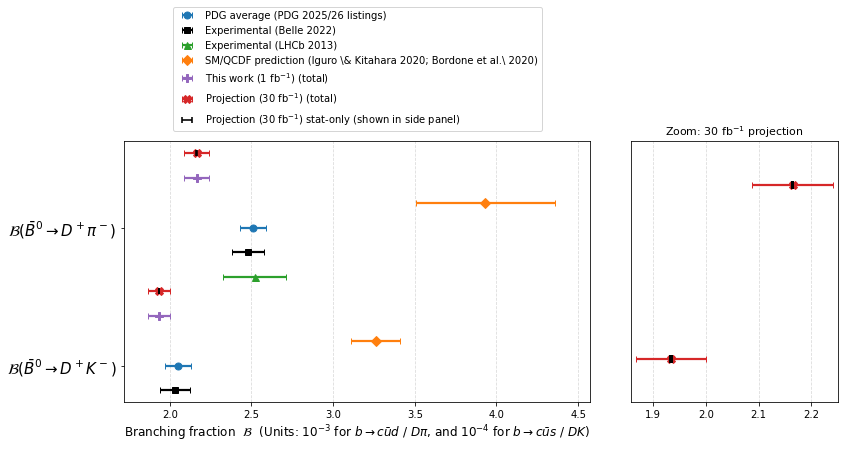

In [8]:
# =========================
# CELL 2 — Forest plot + OUTSIDE zoom panel (right side) for 30 fb^-1 stat-only
# =========================
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import ConnectionPatch, Rectangle

theory_choice = {
    "Dpi": "QCDF (Iguro+Kitahara 2020)",
    "DK":  "QCDF (Bordone+2020)",
}
scale = {"Dpi": 1e-3, "DK": 1e-4}

modes = [
    ("Dpi", r"$\mathcal{B}(\bar{B}^0 \to D^+\pi^-)$"),
    ("DK",  r"$\mathcal{B}(\bar{B}^0 \to D^+K^-)$"),
]
ypos = np.arange(len(modes))[::-1]

def get_row(source, ch_key):
    r = df[(df["source"] == source) & (df["channel_key"] == ch_key)]
    return None if r.empty else r.iloc[0]

styles = {
    "PDG":                   dict(fmt="o", color="tab:blue",   ms=7.0, lw=2.2),
    "Belle":                 dict(fmt="s", color="black",      ms=6.7, lw=2.2),
    "LHCb (2013)":           dict(fmt="^", color="tab:green",  ms=7.0, lw=2.2),
    "SM":                    dict(fmt="D", color="tab:orange", ms=7.0, lw=2.2),
    "This work (1 fb^-1)":   dict(fmt="P", color="tab:purple", ms=7.2, lw=2.2),
    "Projection (30 fb^-1)": dict(fmt="X", color="tab:red",    ms=7.2, lw=2.2),
}

pdg_label   = r"PDG average (PDG 2025/26 listings)"
belle_label = r"Experimental (Belle 2022)"
lhcb_label  = r"Experimental (LHCb 2013)"
sm_label    = r"SM/QCDF prediction (Iguro \& Kitahara 2020; Bordone et al.\ 2020)"
work1_label = r"This work (1 fb$^{-1}$) (total)"
proj_label  = r"Projection (30 fb$^{-1}$) (total)"
proj_stat_label = r"Projection (30 fb$^{-1}$) stat-only (shown in side panel)"

legend_done = set()

dy = {
    "PDG": 0.00,
    "Belle": -0.18,
    "LHCb (2013)": -0.36,
    "SM": +0.18,
    "This work (1 fb^-1)": +0.36,
    "Projection (30 fb^-1)": +0.54,
}

# ---- layout: main plot + outside panel on the right ----
fig = plt.figure(figsize=(12.8, 4.8))
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[3.6, 1.6], wspace=0.12)

ax = fig.add_subplot(gs[0, 0])
ax_zoom = fig.add_subplot(gs[0, 1])

# ---------------------------
# Main axis: plot everything
# ---------------------------
for y, (ch_key, _) in zip(ypos, modes):
    s = scale[ch_key]

    # PDG
    r = get_row("PDG", ch_key)
    if r is not None:
        x = float(r["val"]) / s
        xe_lo = float(r["err_lo"]) / s
        xe_hi = float(r["err_hi"]) / s
        label = pdg_label if "PDG" not in legend_done else None
        legend_done.add("PDG")
        ax.errorbar(x, y + dy["PDG"], xerr=np.array([[xe_lo], [xe_hi]]),
                    capsize=3, label=label, **styles["PDG"])

    # Belle
    r = get_row("Belle", ch_key)
    if r is not None:
        x = float(r["val"]) / s
        xe_lo = float(r["err_lo"]) / s
        xe_hi = float(r["err_hi"]) / s
        label = belle_label if "Belle" not in legend_done else None
        legend_done.add("Belle")
        ax.errorbar(x, y + dy["Belle"], xerr=np.array([[xe_lo], [xe_hi]]),
                    capsize=3, label=label, **styles["Belle"])

    # LHCb
    r = get_row("LHCb (2013)", ch_key)
    if r is not None:
        x = float(r["val"]) / s
        xe_lo = float(r["err_lo"]) / s
        xe_hi = float(r["err_hi"]) / s
        label = lhcb_label if "LHCb" not in legend_done else None
        legend_done.add("LHCb")
        ax.errorbar(x, y + dy["LHCb (2013)"], xerr=np.array([[xe_lo], [xe_hi]]),
                    capsize=3, label=label, **styles["LHCb (2013)"])

    # SM/QCDF
    r = get_row(theory_choice[ch_key], ch_key)
    if r is not None:
        x = float(r["val"]) / s
        xe_lo = float(r["err_lo"]) / s
        xe_hi = float(r["err_hi"]) / s
        label = sm_label if "SM" not in legend_done else None
        legend_done.add("SM")
        ax.errorbar(x, y + dy["SM"], xerr=np.array([[xe_lo], [xe_hi]]),
                    capsize=3, label=label, **styles["SM"])

    # This work total
    r = get_row("This work (1 fb^-1)", ch_key)
    if r is not None:
        x = float(r["val"]) / s
        xe_lo = float(r["err_lo"]) / s
        xe_hi = float(r["err_hi"]) / s
        label = work1_label if "This work (1 fb^-1)" not in legend_done else None
        legend_done.add("This work (1 fb^-1)")
        ax.errorbar(x, y + dy["This work (1 fb^-1)"], xerr=np.array([[xe_lo], [xe_hi]]),
                    capsize=3, label=label, **styles["This work (1 fb^-1)"])

    # Projection total
    r = get_row("Projection (30 fb^-1)", ch_key)
    if r is not None:
        x = float(r["val"]) / s
        xe_lo = float(r["err_lo"]) / s
        xe_hi = float(r["err_hi"]) / s
        label = proj_label if "Projection (30 fb^-1)" not in legend_done else None
        legend_done.add("Projection (30 fb^-1)")
        ax.errorbar(x, y + dy["Projection (30 fb^-1)"], xerr=np.array([[xe_lo], [xe_hi]]),
                    capsize=3, label=label, **styles["Projection (30 fb^-1)"])

    # Stat-only overlay EXACTLY on top (black, no marker): included for correctness, but too small to see here
    r = get_row("Projection (30 fb^-1) stat-only", ch_key)
    if r is not None:
        x = float(r["val"]) / s
        xe_lo = float(r["err_lo"]) / s
        xe_hi = float(r["err_hi"]) / s
        label = proj_stat_label if "Projection stat-only" not in legend_done else None
        legend_done.add("Projection stat-only")
        ax.errorbar(
            x, y + dy["Projection (30 fb^-1)"],
            xerr=np.array([[xe_lo], [xe_hi]]),
            fmt="none",
            ecolor="black",
            elinewidth=1.6,
            capsize=3,
            capthick=1.6,
            zorder=10,
            label=label
        )

ax.set_yticks(ypos)
ax.set_yticklabels([yl for _, yl in modes], fontsize=15)
ax.set_xlabel(
    r"Branching fraction  $\mathcal{B}$  "
    r"(Units: $10^{-3}$ for $b\to c\bar{u}d$ / $D\pi$, and $10^{-4}$ for $b\to c\bar{u}s$ / $DK$)",
    fontsize=12
)
ax.grid(True, axis="x", linestyle="--", alpha=0.45)
ax.grid(False, axis="y")

# x-limits for main axis
xs, xerrs = [], []
for ch_key, _ in modes:
    s = scale[ch_key]
    keep_sources = [
        "PDG", "Belle", "LHCb (2013)", theory_choice[ch_key],
        "This work (1 fb^-1)", "Projection (30 fb^-1)", "Projection (30 fb^-1) stat-only"
    ]
    sub = df[(df["channel_key"] == ch_key) & (df["source"].isin(keep_sources))]
    xs.extend((sub["val"].values / s).tolist())
    xerrs.extend((sub["err_lo"].values / s).tolist())
    xerrs.extend((sub["err_hi"].values / s).tolist())
xmin = min(xs) - 0.5 * max(xerrs)
xmax = max(xs) + 1.5 * max(xerrs)
ax.set_xlim(xmin, xmax)

# Legend above main plot only
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=True)

# ---------------------------
# Side panel: zoom ONLY projection (total + stat-only)
# ---------------------------
proj_points = []
for y, (ch_key, _) in zip(ypos, modes):
    s = scale[ch_key]
    r_tot = get_row("Projection (30 fb^-1)", ch_key)
    r_st  = get_row("Projection (30 fb^-1) stat-only", ch_key)
    if r_tot is None or r_st is None:
        continue

    x = float(r_tot["val"]) / s
    y0 = y + dy["Projection (30 fb^-1)"]

    xe_tot_lo = float(r_tot["err_lo"]) / s
    xe_tot_hi = float(r_tot["err_hi"]) / s
    xe_st_lo  = float(r_st["err_lo"]) / s
    xe_st_hi  = float(r_st["err_hi"]) / s

    ax_zoom.errorbar(
        x, y0,
        xerr=np.array([[xe_tot_lo], [xe_tot_hi]]),
        capsize=3,
        **styles["Projection (30 fb^-1)"]
    )
    ax_zoom.errorbar(
        x, y0,
        xerr=np.array([[xe_st_lo], [xe_st_hi]]),
        fmt="none",
        ecolor="black",
        elinewidth=2.0,
        capsize=4,
        capthick=2.0,
        zorder=10
    )
    proj_points.append((x, xe_tot_lo, xe_tot_hi, y0))

# Make the side panel look like an inset
ax_zoom.set_title(r"Zoom: 30 fb$^{-1}$ projection", fontsize=11)
ax_zoom.set_yticks([])
ax_zoom.grid(True, axis="x", linestyle="--", alpha=0.45)
ax_zoom.grid(False, axis="y")

ys_inset = [p[-1] for p in proj_points]
ax_zoom.set_ylim(min(ys_inset) - 0.25, max(ys_inset) + 0.25)

# tight x limits around projection points (using total errors)
x_left  = min(x - (xe_lo + 0.01) for x, xe_lo, _, _ in proj_points)
x_right = max(x + (xe_hi + 0.01) for x, _, xe_hi, _ in proj_points)
ax_zoom.set_xlim(x_left, x_right)

# ---------------------------
# Draw a rectangle on main axis indicating zoom region + connectors to side panel
# ---------------------------
# rectangle spans the x-range of the zoom panel, and the y-range covering both projection rows
rect_ymin = min(ys_inset) - 0.25
rect_ymax = max(ys_inset) + 0.25
rect = Rectangle((x_left, rect_ymin), x_right - x_left, rect_ymax - rect_ymin,
                 fill=False, ec="0.4", lw=1.2)



plt.show()

In [9]:
"""
forest_plots.py
Generates all forest plot variants as 300 DPI PNGs.

Output files:
  plot1_forest_basic.png          – PDG / Belle / LHCb / QCDF  (no "this work")
  plot2_forest_with_results.png   – + This work (1 fb⁻¹) + Projection (30 fb⁻¹)
  plot3_forest_stat_overlay.png   – same + stat-only overlay on projection row
  plot4_forest_zoom_panel.png     – same + outside zoom panel on the right
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.gridspec import GridSpec

# ── helpers ──────────────────────────────────────────────────────────────────

def quad(*xs):
    return float(np.sqrt(np.sum(np.array(xs, dtype=float) ** 2)))


channels = {
    "Dpi": r"$\bar{B}^0\!\to\! D^+\pi^-$",
    "DK":  r"$\bar{B}^0\!\to\! D^+K^-$",
}

theory_choice = {
    "Dpi": "QCDF (Iguro+Kitahara 2020)",
    "DK":  "QCDF (Bordone+2020)",
}

# scaled units: Dπ in 10⁻³, DK in 10⁻⁴
scale = {"Dpi": 1e-3, "DK": 1e-4}
scale_label = {"Dpi": r"$10^{-3}$", "DK": r"$10^{-4}$"}

modes = [
    ("Dpi", r"$\mathcal{B}(\bar{B}^0 \to D^+\pi^-)$"
            "\n" r"[units: $10^{-3}$]"),
    ("DK",  r"$\mathcal{B}(\bar{B}^0 \to D^+K^-)$"
            "\n" r"[units: $10^{-4}$]"),
]
ypos = np.arange(len(modes))[::-1]   # Dπ on top

styles = {
    "PDG":                    dict(fmt="o",  color="tab:blue",   ms=7.0, lw=2.2),
    "Belle":                  dict(fmt="s",  color="black",      ms=6.7, lw=2.2),
    "LHCb (2013)":            dict(fmt="^",  color="tab:green",  ms=7.0, lw=2.2),
    "SM":                     dict(fmt="D",  color="tab:orange", ms=7.0, lw=2.2),
    "This work (1 fb^-1)":    dict(fmt="P",  color="tab:purple", ms=7.2, lw=2.2),
    "Projection (30 fb^-1)":  dict(fmt="X",  color="tab:red",    ms=7.2, lw=2.2),
}

# vertical offsets within each mode row (to avoid overlap)
dy = {
    "PDG":                   0.00,
    "Belle":                -0.18,
    "LHCb (2013)":          -0.36,
    "SM":                   +0.18,
    "This work (1 fb^-1)":  +0.36,
    "Projection (30 fb^-1)":+0.54,
}

XLABEL = (
    r"Branching fraction  $\mathcal{B}$"
    "\n"
    r"(Units: $10^{-3}$ for $D\pi$,  $10^{-4}$ for $DK$)"
)

# ── data builder ─────────────────────────────────────────────────────────────

def build_df(include_this_work=False, include_proj=False, include_stat_only=False):
    pdg = {
        "Dpi": dict(val=2.51e-3, err_lo=0.08e-3,  err_hi=0.08e-3),
        "DK":  dict(val=2.05e-4, err_lo=0.08e-4,  err_hi=0.08e-4),
    }
    belle = {
        "Dpi": dict(val=2.48e-3,
                    err_lo=quad(0.01e-3, 0.09e-3, 0.04e-3),
                    err_hi=quad(0.01e-3, 0.09e-3, 0.04e-3)),
        "DK":  dict(val=2.03e-4,
                    err_lo=quad(0.05e-4, 0.07e-4, 0.03e-4),
                    err_hi=quad(0.05e-4, 0.07e-4, 0.03e-4)),
    }
    lhcb_2013 = {
        "Dpi": dict(val=2.52e-3,
                    err_lo=quad(0.13e-3, 0.09e-3, 0.11e-3),
                    err_hi=quad(0.13e-3, 0.09e-3, 0.11e-3)),
    }
    bordone_qcdf = {
        "DK": dict(val=0.326e-3, err_lo=0.015e-3, err_hi=0.015e-3),
    }
    iguro_qcdf = {
        "Dpi": dict(val=3.93e-3, err_lo=0.42e-3, err_hi=0.43e-3),
    }
    this_work = {
        "Dpi": dict(val=2.1646e-3,
                    err_lo=quad(0.0073e-3, 0.0764e-3),
                    err_hi=quad(0.0073e-3, 0.0764e-3)),
        "DK":  dict(val=1.9333e-4,
                    err_lo=quad(0.0137e-4, 0.0661e-4),
                    err_hi=quad(0.0137e-4, 0.0661e-4)),
    }
    proj_total = {
        "Dpi": dict(val=2.1646e-3,
                    err_lo=quad(0.0013e-3, 0.0764e-3),
                    err_hi=quad(0.0013e-3, 0.0764e-3)),
        "DK":  dict(val=1.9333e-4,
                    err_lo=quad(0.0025e-4, 0.0661e-4),
                    err_hi=quad(0.0025e-4, 0.0661e-4)),
    }
    proj_stat = {
        "Dpi": dict(val=2.1646e-3, err_lo=0.0013e-3, err_hi=0.0013e-3),
        "DK":  dict(val=1.9333e-4, err_lo=0.0025e-4, err_hi=0.0025e-4),
    }

    records = []

    def add(src_dict, source_name):
        for ch, d in src_dict.items():
            records.append(dict(
                channel_key=ch,
                source=source_name,
                val=d["val"],
                err_lo=d["err_lo"],
                err_hi=d["err_hi"],
            ))

    add(pdg,          "PDG")
    add(belle,        "Belle")
    add(lhcb_2013,    "LHCb (2013)")
    add(bordone_qcdf, "QCDF (Bordone+2020)")
    add(iguro_qcdf,   "QCDF (Iguro+Kitahara 2020)")
    if include_this_work:
        add(this_work, "This work (1 fb^-1)")
    if include_proj:
        add(proj_total, "Projection (30 fb^-1)")
    if include_stat_only:
        add(proj_stat,  "Projection (30 fb^-1) stat-only")

    return pd.DataFrame.from_records(records)


def get_row(df, source, ch_key):
    r = df[(df["source"] == source) & (df["channel_key"] == ch_key)]
    return None if r.empty else r.iloc[0]


def xlimits(df, ch_key, keep_sources, pad_lo=0.5, pad_hi=1.5):
    s = scale[ch_key]
    sub = df[(df["channel_key"] == ch_key) & (df["source"].isin(keep_sources))]
    xs    = (sub["val"].values / s).tolist()
    errs  = (sub["err_lo"].values / s).tolist() + (sub["err_hi"].values / s).tolist()
    return min(xs) - pad_lo * max(errs), max(xs) + pad_hi * max(errs)


# ── per-axis rendering helper ─────────────────────────────────────────────────

def plot_sources(ax, df, sources_to_plot, legend_labels):
    """
    sources_to_plot : list of source-name strings to draw (in that order)
    legend_labels   : dict mapping source-name → legend string (or None to skip)
    """
    legend_done = set()

    for y, (ch_key, _) in zip(ypos, modes):
        s = scale[ch_key]

        for src in sources_to_plot:
            r = get_row(df, src, ch_key)
            if r is None:
                continue

            x     = float(r["val"])    / s
            xe_lo = float(r["err_lo"]) / s
            xe_hi = float(r["err_hi"]) / s

            lbl_key = legend_labels.get(src)
            label   = lbl_key if (lbl_key and lbl_key not in legend_done) else None
            if lbl_key:
                legend_done.add(lbl_key)

            # "Projection stat-only" has its own draw style
            if src == "Projection (30 fb^-1) stat-only":
                ax.errorbar(
                    x, y + dy["Projection (30 fb^-1)"] + 0.08,
                    xerr=np.array([[xe_lo], [xe_hi]]),
                    fmt="none",
                    ecolor="black",
                    elinewidth=2.2,
                    capsize=8,
                    capthick=2.2,
                    zorder=10,
                    label=label,
                )
            else:
                # map source name → style key
                sk = {
                    "PDG":                    "PDG",
                    "Belle":                  "Belle",
                    "LHCb (2013)":            "LHCb (2013)",
                    "QCDF (Iguro+Kitahara 2020)": "SM",
                    "QCDF (Bordone+2020)":    "SM",
                    "This work (1 fb^-1)":    "This work (1 fb^-1)",
                    "Projection (30 fb^-1)":  "Projection (30 fb^-1)",
                }.get(src, "PDG")

                offset_key = src if src in dy else (
                    "SM" if "QCDF" in src else "PDG"
                )
                ax.errorbar(
                    x, y + dy[offset_key],
                    xerr=np.array([[xe_lo], [xe_hi]]),
                    capsize=3,
                    label=label,
                    **styles[sk],
                )

    ax.set_yticks(ypos)
    ax.set_yticklabels([yl for _, yl in modes], fontsize=14)
    ax.set_xlabel(XLABEL, fontsize=11)
    ax.grid(True, axis="x", linestyle="--", alpha=0.45)
    ax.grid(False, axis="y")


# ═══════════════════════════════════════════════════════════════════════════
# PLOT 1 — Basic: PDG / Belle / LHCb / QCDF
# ═══════════════════════════════════════════════════════════════════════════

def make_plot1():
    df = build_df()

    sources = [
        "PDG",
        "Belle",
        "LHCb (2013)",
        "QCDF (Iguro+Kitahara 2020)",
        "QCDF (Bordone+2020)",
    ]
    labels = {
        "PDG":                        r"PDG average (PDG 2025/26)",
        "Belle":                      r"Experimental (Belle 2022)",
        "LHCb (2013)":                r"Experimental (LHCb 2013)",
        "QCDF (Iguro+Kitahara 2020)": r"SM/QCDF prediction (Iguro & Kitahara 2020; Bordone et al. 2020)",
        "QCDF (Bordone+2020)":        r"SM/QCDF prediction (Iguro & Kitahara 2020; Bordone et al. 2020)",
    }

    fig, ax = plt.subplots(figsize=(10, 4.4))
    plot_sources(ax, df, sources, labels)

    # x limits: widest window across both modes
    lo_pi, hi_pi = xlimits(df, "Dpi", ["PDG", "Belle", "LHCb (2013)", "QCDF (Iguro+Kitahara 2020)"])
    lo_dk, hi_dk = xlimits(df, "DK",  ["PDG", "Belle", "QCDF (Bordone+2020)"])
    ax.set_xlim(min(lo_pi, lo_dk), max(hi_pi, hi_dk))

    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=True, fontsize=9)
    fig.suptitle(
        r"Branching fractions: $\bar{B}^0\!\to\!D^+\pi^-$ and $\bar{B}^0\!\to\!D^+K^-$",
        y=1.14, fontsize=12,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.88])
    plt.savefig("plot1_forest_basic.png", dpi=300, bbox_inches="tight")
    plt.close()
    print("Saved plot1_forest_basic.png")


# ═══════════════════════════════════════════════════════════════════════════
# PLOT 2 — + This work (1 fb⁻¹) + Projection (30 fb⁻¹)
# ═══════════════════════════════════════════════════════════════════════════

def make_plot2():
    df = build_df(include_this_work=True, include_proj=True)

    sources = [
        "PDG", "Belle", "LHCb (2013)",
        "QCDF (Iguro+Kitahara 2020)", "QCDF (Bordone+2020)",
        "This work (1 fb^-1)",
        "Projection (30 fb^-1)",
    ]
    labels = {
        "PDG":                        r"PDG average (PDG 2025/26)",
        "Belle":                      r"Experimental (Belle 2022)",
        "LHCb (2013)":                r"Experimental (LHCb 2013)",
        "QCDF (Iguro+Kitahara 2020)": r"SM/QCDF prediction (Iguro & Kitahara 2020; Bordone et al. 2020)",
        "QCDF (Bordone+2020)":        r"SM/QCDF prediction (Iguro & Kitahara 2020; Bordone et al. 2020)",
        "This work (1 fb^-1)":        r"This work (1 fb$^{-1}$, total unc.)",
        "Projection (30 fb^-1)":      r"Projection (30 fb$^{-1}$, total unc.)",
    }

    fig, ax = plt.subplots(figsize=(10, 4.8))
    plot_sources(ax, df, sources, labels)

    all_src = sources
    lo_pi, hi_pi = xlimits(df, "Dpi", all_src)
    lo_dk, hi_dk = xlimits(df, "DK",  all_src)
    ax.set_xlim(min(lo_pi, lo_dk), max(hi_pi, hi_dk))

    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=True, fontsize=9)
    fig.suptitle(
        r"Branching fractions: $\bar{B}^0\!\to\!D^+\pi^-$ and $\bar{B}^0\!\to\!D^+K^-$",
        y=1.16, fontsize=12,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.86])
    plt.savefig("plot2_forest_with_results.png", dpi=300, bbox_inches="tight")
    plt.close()
    print("Saved plot2_forest_with_results.png")


# ═══════════════════════════════════════════════════════════════════════════
# PLOT 3 — + stat-only overlay on the projection row
# ═══════════════════════════════════════════════════════════════════════════

def make_plot3():
    df = build_df(include_this_work=True, include_proj=True, include_stat_only=True)

    sources = [
        "PDG", "Belle", "LHCb (2013)",
        "QCDF (Iguro+Kitahara 2020)", "QCDF (Bordone+2020)",
        "This work (1 fb^-1)",
        "Projection (30 fb^-1)",
        "Projection (30 fb^-1) stat-only",
    ]
    labels = {
        "PDG":                                r"PDG average (PDG 2025/26)",
        "Belle":                              r"Experimental (Belle 2022)",
        "LHCb (2013)":                        r"Experimental (LHCb 2013)",
        "QCDF (Iguro+Kitahara 2020)":         r"SM/QCDF (Iguro & Kitahara 2020; Bordone et al. 2020)",
        "QCDF (Bordone+2020)":                r"SM/QCDF (Iguro & Kitahara 2020; Bordone et al. 2020)",
        "This work (1 fb^-1)":                r"This work (1 fb$^{-1}$, total unc.)",
        "Projection (30 fb^-1)":              r"Projection (30 fb$^{-1}$, total unc.) [coloured]",
        "Projection (30 fb^-1) stat-only":    r"Projection (30 fb$^{-1}$, stat-only) [black, offset]",
    }

    fig, ax = plt.subplots(figsize=(10, 4.8))
    plot_sources(ax, df, sources, labels)

    all_src = [s for s in sources if "stat-only" not in s]
    lo_pi, hi_pi = xlimits(df, "Dpi", all_src)
    lo_dk, hi_dk = xlimits(df, "DK",  all_src)
    ax.set_xlim(min(lo_pi, lo_dk), max(hi_pi, hi_dk))

    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=True, fontsize=9)
    fig.suptitle(
        r"Branching fractions: $\bar{B}^0\!\to\!D^+\pi^-$ and $\bar{B}^0\!\to\!D^+K^-$"
        "\n(red = total unc., black caps = stat-only for 30 fb⁻¹ projection)",
        y=1.18, fontsize=11,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.84])
    plt.savefig("plot3_forest_stat_overlay.png", dpi=300, bbox_inches="tight")
    plt.close()
    print("Saved plot3_forest_stat_overlay.png")


# ═══════════════════════════════════════════════════════════════════════════
# PLOT 4 — + side-panel zoom of the 30 fb⁻¹ projection
# ═══════════════════════════════════════════════════════════════════════════

def make_plot4():
    df = build_df(include_this_work=True, include_proj=True, include_stat_only=True)

    sources_main = [
        "PDG", "Belle", "LHCb (2013)",
        "QCDF (Iguro+Kitahara 2020)", "QCDF (Bordone+2020)",
        "This work (1 fb^-1)",
        "Projection (30 fb^-1)",
        "Projection (30 fb^-1) stat-only",
    ]
    labels = {
        "PDG":                             r"PDG average (PDG 2025/26)",
        "Belle":                           r"Experimental (Belle 2022)",
        "LHCb (2013)":                     r"Experimental (LHCb 2013)",
        "QCDF (Iguro+Kitahara 2020)":      r"SM/QCDF (Iguro & Kitahara 2020; Bordone et al. 2020)",
        "QCDF (Bordone+2020)":             r"SM/QCDF (Iguro & Kitahara 2020; Bordone et al. 2020)",
        "This work (1 fb^-1)":             r"This work (1 fb$^{-1}$, total unc.)",
        "Projection (30 fb^-1)":           r"Projection (30 fb$^{-1}$, total unc.)",
        "Projection (30 fb^-1) stat-only": r"Projection (30 fb$^{-1}$, stat-only) [side panel]",
    }

    fig = plt.figure(figsize=(13.5, 5.0))
    gs  = GridSpec(1, 2, figure=fig, width_ratios=[3.4, 1.6], wspace=0.10)
    ax      = fig.add_subplot(gs[0, 0])
    ax_zoom = fig.add_subplot(gs[0, 1])

    # ── main axis ────────────────────────────────────────────────────────────
    plot_sources(ax, df, sources_main, labels)

    all_src = [s for s in sources_main if "stat-only" not in s]
    lo_pi, hi_pi = xlimits(df, "Dpi", all_src)
    lo_dk, hi_dk = xlimits(df, "DK",  all_src)
    ax.set_xlim(min(lo_pi, lo_dk), max(hi_pi, hi_dk))

    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=True, fontsize=8.5)

    # ── side zoom panel ───────────────────────────────────────────────────────
    proj_pts = []   # (x, xe_tot_lo, xe_tot_hi, y0)

    for y, (ch_key, ch_lbl) in zip(ypos, modes):
        s = scale[ch_key]
        r_tot = get_row(df, "Projection (30 fb^-1)",          ch_key)
        r_st  = get_row(df, "Projection (30 fb^-1) stat-only", ch_key)
        if r_tot is None or r_st is None:
            continue

        x      = float(r_tot["val"])    / s
        y0     = y + dy["Projection (30 fb^-1)"]
        xelo_t = float(r_tot["err_lo"]) / s
        xehi_t = float(r_tot["err_hi"]) / s
        xelo_s = float(r_st["err_lo"])  / s
        xehi_s = float(r_st["err_hi"])  / s

        ax_zoom.errorbar(
            x, y0,
            xerr=np.array([[xelo_t], [xehi_t]]),
            capsize=3,
            **styles["Projection (30 fb^-1)"],
        )
        ax_zoom.errorbar(
            x, y0,
            xerr=np.array([[xelo_s], [xehi_s]]),
            fmt="none",
            ecolor="black",
            elinewidth=2.0,
            capsize=5,
            capthick=2.0,
            zorder=10,
        )
        # channel label on zoom axis
        ax_zoom.text(
            x, y0 - 0.15,
            ch_lbl,
            ha="center", va="top", fontsize=8,
        )
        proj_pts.append((x, xelo_t, xehi_t, y0))

    # zoom axis cosmetics
    ax_zoom.set_title(
        r"Zoom: 30 fb$^{-1}$ projection" "\n"
        r"(red = total, black = stat-only)",
        fontsize=9.5,
    )
    ax_zoom.set_xlabel(XLABEL, fontsize=9)
    ax_zoom.set_yticks([])
    ax_zoom.grid(True, axis="x", linestyle="--", alpha=0.45)

    ys_inset = [p[-1] for p in proj_pts]
    ax_zoom.set_ylim(min(ys_inset) - 0.35, max(ys_inset) + 0.35)

    x_left  = min(x - (xe_lo + 0.02) for x, xe_lo, _, _ in proj_pts)
    x_right = max(x + (xe_hi + 0.02) for x, _, xe_hi, _ in proj_pts)
    ax_zoom.set_xlim(x_left, x_right)

    # rectangle on main axis indicating the zoom region
    rect_ymin = min(ys_inset) - 0.35
    rect_ymax = max(ys_inset) + 0.35
    rect = Rectangle(
        (x_left, rect_ymin),
        x_right - x_left,
        rect_ymax - rect_ymin,
        fill=False, ec="0.4", lw=1.2, linestyle="--",
    )
    ax.add_patch(rect)

    fig.suptitle(
        r"Branching fractions: $\bar{B}^0\!\to\!D^+\pi^-$ and $\bar{B}^0\!\to\!D^+K^-$",
        y=1.12, fontsize=12,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.savefig("plot4_forest_zoom_panel.png", dpi=300, bbox_inches="tight")
    plt.close()
    print("Saved plot4_forest_zoom_panel.png")


# ── run ──────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    make_plot1()
    make_plot2()
    make_plot3()
    make_plot4()
    print("\nAll plots saved successfully.")

Saved plot1_forest_basic.png
Saved plot2_forest_with_results.png
Saved plot3_forest_stat_overlay.png



/tmp/user/ipykernel_3372058/3179755882.py:468: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.90])



Saved plot4_forest_zoom_panel.png

All plots saved successfully.

